In [125]:
import os, sys
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(PROJECT_ROOT)

In [126]:
import pandas as pd
from utils import *

In [127]:
df = pd.read_csv('data/listings_edited.csv').drop_duplicates().dropna(subset=['price']).reset_index(drop=True)
df.shape

(4727, 40)

In [128]:
import ast
df.amenities = df.amenities.apply(ast.literal_eval)
df.price = df.price.str.replace('\$', '', regex=True).str.replace(',', '').astype(float)

In [129]:
df.amenities

0       [Patio or balcony, Dishes and silverware, Lugg...
1       [Patio or balcony, Free parking on premises, D...
2       [Dishes and silverware, Private patio or balco...
3       [Backyard, TV, Patio or balcony, Free parking ...
4       [Diverse body soap, Free washer – In building,...
                              ...                        
4722    [TV, Carbon monoxide alarm, Free parking on pr...
4723    [TV, Dishes and silverware, Luggage dropoff al...
4724        [TV, Washer, Kitchen, Air conditioning, Wifi]
4725    [TV, Dishes and silverware, Washer, Body soap,...
4726    [Patio or balcony, Free parking on premises, D...
Name: amenities, Length: 4727, dtype: object

In [130]:
from collections import Counter
amenities = Counter([amenity for sublist in df['amenities'] for amenity in sublist])
amenities

Counter({'Wifi': 4261,
         'Kitchen': 4126,
         'Smoke alarm': 4085,
         'Hot water': 3289,
         'Hair dryer': 3198,
         'Dishes and silverware': 2995,
         'Essentials': 2986,
         'Bed linens': 2888,
         'Hangers': 2829,
         'Dedicated workspace': 2814,
         'Cooking basics': 2601,
         'Refrigerator': 2586,
         'Washer': 2542,
         'Iron': 2498,
         'TV': 2318,
         'Heating': 2201,
         'Hot water kettle': 2105,
         'Room-darkening shades': 2007,
         'Shampoo': 1991,
         'Dining table': 1890,
         'Dishwasher': 1853,
         'Body soap': 1675,
         'Wine glasses': 1672,
         'Shower gel': 1659,
         'Cleaning products': 1611,
         'Bathtub': 1600,
         'Freezer': 1581,
         'Extra pillows and blankets': 1522,
         'Oven': 1512,
         'Elevator': 1505,
         'Long term stays allowed': 1418,
         'First aid kit': 1390,
         'Microwave': 1368,
         

In [131]:
top_amenities = [amenity for amenity, count in amenities.items() if count >= 100]
top_amenities

['Patio or balcony',
 'Dishes and silverware',
 'Luggage dropoff allowed',
 'Free street parking',
 'Hair dryer',
 'Refrigerator',
 'Window guards',
 'Room-darkening shades',
 'Bathtub',
 'Cleaning available during stay',
 'Dishwasher',
 'Kitchen',
 'Hot water',
 'Long term stays allowed',
 'Shampoo',
 'Bed linens',
 'Private entrance',
 'Toaster',
 'TV with standard cable',
 'Oven',
 'Wifi',
 'Hangers',
 'Essentials',
 'Carbon monoxide alarm',
 'Microwave',
 'Hot water kettle',
 'Coffee maker',
 'Wine glasses',
 'Children’s books and toys',
 'Dining table',
 'Stove',
 'Heating',
 'Host greets you',
 'Extra pillows and blankets',
 'Smoke alarm',
 'Cooking basics',
 'Free parking on premises',
 'Washer',
 'Dryer',
 'Dedicated workspace',
 'Baking sheet',
 'Iron',
 'Private backyard – Fully fenced',
 'Private patio or balcony',
 'EV charger',
 'Fire extinguisher',
 'Elevator',
 'First aid kit',
 'Single level home',
 'Pack ’n play/Travel crib',
 'Crib',
 'Pets allowed',
 'Backyard',
 'TV

<Axes: ylabel='price'>

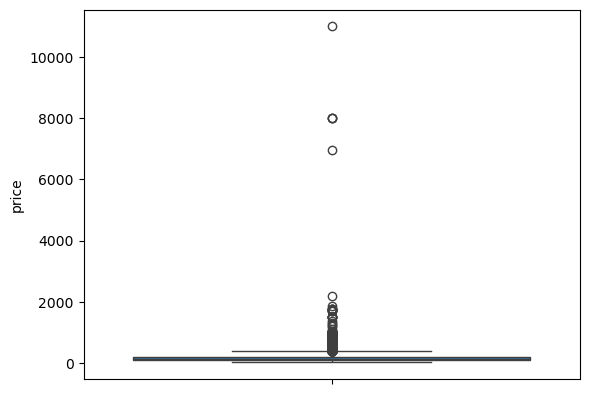

In [133]:
sns.boxplot(df.price)

<Axes: ylabel='price'>

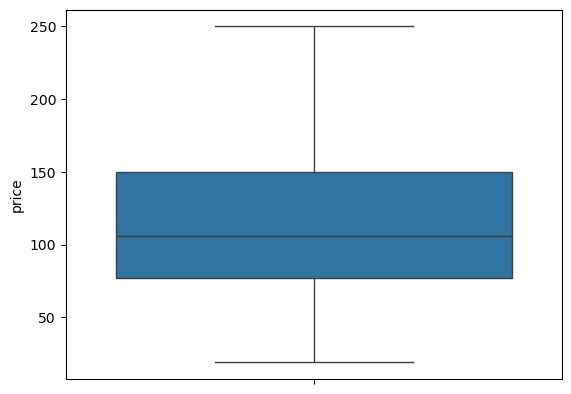

In [134]:
df = df[df.price <= 250]
sns.boxplot(df.price)

In [135]:
df[df.price <= 250].reset_index(drop=True).price.isna().sum()

0

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer
df.amenities = df.amenities.apply(lambda row: [amenity if amenity in top_amenities else 'Other' for amenity in row])
df = df[df.price <= 250].reset_index(drop=True)
mlb = MultiLabelBinarizer()
amenities_encoded = mlb.fit_transform(df.amenities)
df_amenities = pd.DataFrame(amenities_encoded, columns=mlb.classes_)
df_amenities.head()
df_model = pd.concat([df[['price']], df_amenities], axis=1)
df_model[df_model.isna().any(axis=1)]

,price,Air conditioning,BBQ grill,Backyard,Baking sheet,Barbecue utensils,Bathtub,Bed linens,Bikes,Blender,...,Stainless steel oven,Stove,Sun loungers,TV,TV with standard cable,Toaster,Washer,Wifi,Window guards,Wine glasses


In [148]:
import statsmodels.api as sm

df_model = pd.concat([df[['price']], df_amenities], axis=1)

X = df_model.drop(columns='price')
y = df_model['price']
X = sm.add_constant(X)

X.head()

,const,Air conditioning,BBQ grill,Backyard,Baking sheet,Barbecue utensils,Bathtub,Bed linens,Bikes,Blender,...,Stainless steel oven,Stove,Sun loungers,TV,TV with standard cable,Toaster,Washer,Wifi,Window guards,Wine glasses
0,1.0,0,0,0,0,0,1,1,0,0,...,0,1,0,0,1,1,0,1,1,1
1,1.0,0,0,0,1,0,0,1,0,0,...,0,1,0,0,1,0,1,1,0,0
2,1.0,0,0,0,0,0,1,1,0,0,...,0,1,0,0,1,0,1,1,0,0
3,1.0,0,0,1,0,0,0,1,0,0,...,0,1,0,1,0,1,0,1,0,1
4,1.0,0,0,0,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,1


In [149]:
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.213
Model:                            OLS   Adj. R-squared:                  0.187
Method:                 Least Squares   F-statistic:                     8.413
Date:                Sun, 23 Mar 2025   Prob (F-statistic):          4.43e-125
Time:                        16:09:00   Log-Likelihood:                -21106.
No. Observations:                3990   AIC:                         4.246e+04
Df Residuals:                    3865   BIC:                         4.325e+04
Df Model:                         124                                         
Covariance Type:            nonrobust                                         
==========================================================================================================
                                             coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
const                                    127.1849      4.431     28.703      0.000     118.497     135.872
Air conditioning                           2.3335      3.619      0.645      0.519      -4.763       9.430
BBQ grill                                 -1.0905      3.538     -0.308      0.758      -8.026       5.845
Backyard                                  -7.8532      3.027     -2.595      0.010     -13.787      -1.919
Baking sheet                               2.4102      2.709      0.890      0.374      -2.902       7.722
Barbecue utensils                         -6.7109      4.415     -1.520      0.129     -15.368       1.946
Bathtub                                    3.5725      2.037      1.754      0.080      -0.421       7.566
Bed linens                                 2.0760      2.664      0.779      0.436      -3.148       7.300
Bikes                                     -6.4596      4.620     -1.398      0.162     -15.518       2.599
Blender                                    2.7442      2.796      0.981      0.326      -2.738       8.227
Board games                                0.6449      3.639      0.177      0.859      -6.489       7.779
Body soap                                  3.1176      2.395      1.302      0.193      -1.578       7.814
Books and reading material                 1.7844      2.482      0.719      0.472      -3.082       6.651
Building staff                            12.6982      8.585      1.479      0.139      -4.133      29.529
Carbon monoxide alarm                     -1.9433      2.010     -0.967      0.334      -5.884       1.998
Central heating                            1.4759      3.208      0.460      0.646      -4.814       7.766
Children’s books and toys                  0.7636      4.774      0.160      0.873      -8.596      10.123
Children’s dinnerware                      6.5774      5.178      1.270      0.204      -3.575      16.730
City skyline view                          6.6390      5.315      1.249      0.212      -3.781      17.059
Cleaning available during stay             1.7958      2.977      0.603      0.546      -4.041       7.632
Cleaning products                         -0.6994      2.388     -0.293      0.770      -5.381       3.983
Clothing storage                           1.5097      2.863      0.527      0.598      -4.104       7.123
Clothing storage: closet                  -0.0498      4.113     -0.012      0.990      -8.114       8.014
Clothing storage: dresser                 -3.0993      5.359     -0.578      0.563     -13.605       7.407
Clothing storage: wardrobe                -4.9458      2.826     -1.750      0.080     -10.486       0.594
Clothing storage: wardrobe and dresser     4.4467      5.211      0.853      0.394     

In [151]:
sig_amens = model.pvalues[model.pvalues < 0.05].index
sig_coefs = model.params[sig_amens].sort_values(ascending=False)
sig_coefs

const                              127.184915
Crib - available upon request       27.385297
Smart lock                          17.177524
Crib                                12.916623
Dishwasher                          10.699490
High chair                          10.001177
Safe                                 9.680997
Private entrance                     8.464957
Patio or balcony                     7.766072
Ethernet connection                  7.285328
TV                                   7.234308
Private patio or balcony             6.436313
Coffee                               5.388763
First aid kit                        4.434830
Hangers                             -4.920971
Fire extinguisher                   -5.159870
Hot water                           -6.097342
Mini fridge                         -6.213199
Hot water kettle                    -6.303117
Cooking basics                      -6.811998
Garden view                         -6.936746
Dishes and silverware             

In [159]:
df_with_TV = df[df.amenities.apply(lambda row: any('TV' in amenity for amenity in row))]
df_without_TV = df[~df.index.isin(df_with_TV.index)]
price_with_TV = df_with_TV.price.mean()
price_without_TV = df_without_TV.price.mean()
price_with_TV, price_without_TV

(122.70452446906741, 112.29989035087719)

In [157]:
price_with_TV - price_without_TV

10.404634118190216

In [164]:
import dataprep.eda as dp
dp.plot_diff([df_with_TV.drop(columns=['amenities']), df_without_TV.drop(columns=['amenities'])]).save('compare_tv.html')

In [165]:
df_with_fe = df[df.amenities.apply(lambda row: any('Fire extinguisher' in amenity for amenity in row))]
df_without_fe = df[~df.index.isin(df_with_fe.index)]
price_with_fe = df_with_fe.price.mean()
price_without_fe = df_without_fe.price.mean()
price_with_fe, price_without_fe

(115.3375241779497, 118.86129905277402)

In [166]:
price_with_fe - price_without_fe

-3.523774874824312

In [167]:
dp.plot_diff([df_with_fe.drop(columns=['amenities']), df_without_fe.drop(columns=['amenities'])]).save('compare_fe.html')